# Member 5 — Multi-Layer Perceptron & Decision Tree
**COM3032/COMM074 · Airline Route Profitability · CRISP-DM: Modelling & Evaluation**

**Student:** Member 5
**Primary Model:** Multi-Layer Perceptron (MLPClassifier)
**Member 5 – Decision Tree:** Tuned with entropy criterion, heavy regularisation via large min-samples
**Data:** Scaled for MLP (gradient-based optimisation is scale-sensitive); Unscaled for Decision Tree

---

### Metric Justification

| Metric | Business Meaning |
|--------|------------------|
| F1-Score | Primary metric — balances precision and recall for imbalanced classification. |
| ROC-AUC | Ranking ability across all thresholds — used for cross-member comparison. |
| MCC | Accounts for all four confusion matrix cells. Above 0.4 = genuine discriminative ability. |
| TPR (Recall) | Fraction of profitable routes correctly identified. |
| TNR | Fraction of loss-making routes correctly flagged. |
| FPR | Fraction of loss-making routes wrongly approved. Drives financial cost. |
| Overfit Gap | Train F1 minus Test F1. < 0.05 = good fit; 0.05–0.10 = borderline; > 0.10 = memorising. |

## Section 1 — Imports and Setup

All libraries loaded. Paths point to shared `processed_data/` folder.

In [1]:
import os, json, pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (RandomizedSearchCV, GridSearchCV,
                                     StratifiedKFold, cross_val_score, learning_curve)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report,
                              matthews_corrcoef)
print('Libraries loaded.')

Libraries loaded.


## Section 2 — Load Data

MLP uses **scaled** feature splits — gradient-based optimisation is sensitive to feature magnitude. Features on very different scales cause gradients to oscillate, slowing convergence. Decision Tree uses unscaled data.

In [2]:
from pathlib import Path

RANDOM_STATE = 42
FP_COST      = 42000
FN_COST      = 30000

MEMBER_DIR = Path.cwd()
BASE       = MEMBER_DIR.parent
PROC       = BASE / "processed_data"
FIG_DIR    = MEMBER_DIR
MEMBER_DIR.mkdir(parents=True, exist_ok=True)

print("Member dir:", MEMBER_DIR)
print("Processed folder:", PROC)
print("Processed folder exists:", PROC.exists())

X_train   = pd.read_csv(PROC / "X_train.csv")
X_val     = pd.read_csv(PROC / "X_val.csv")
X_test    = pd.read_csv(PROC / "X_test.csv")

X_train_s = pd.read_csv(PROC / "X_train_scaled.csv")
X_val_s   = pd.read_csv(PROC / "X_val_scaled.csv")
X_test_s  = pd.read_csv(PROC / "X_test_scaled.csv")

y_train = pd.read_csv(PROC / "y_train.csv").squeeze()
y_val   = pd.read_csv(PROC / "y_val.csv").squeeze()
y_test  = pd.read_csv(PROC / "y_test.csv").squeeze()

with open(PROC / "feature_names.json") as f:
    feature_names = json.load(f)

C_PROFIT  = '#2DC653'
C_LOSS    = '#E84855'
C_NEUTRAL = '#2E86AB'

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Class balance — Train: {y_train.mean():.3f}, Val: {y_val.mean():.3f}, Test: {y_test.mean():.3f}')

Member dir: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\Member 5
Processed folder: c:\Users\Hiral Mistry\OneDrive\Documents\MSc DS Surrey\Data Visualisation\BADV\airline_project\processed_data
Processed folder exists: True
Train: (11997, 37), Val: (1500, 37), Test: (1500, 37)
Class balance — Train: 0.637, Val: 0.637, Test: 0.637


## Section 3 — Utility Functions

Identical utility function suite across all five members for consistent evaluation.

In [3]:

def evaluate(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1_Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC_AUC'  : round(roc_auc_score(y_true, y_prob), 4)
    }

def evaluate_enhanced(name, model, X_tr, y_tr, X_te, y_te):
    y_pred    = model.predict(X_te)
    y_prob    = model.predict_proba(X_te)[:, 1]
    y_pred_tr = model.predict(X_tr)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)
    mcc  = matthews_corrcoef(y_te, y_pred)

    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    f1_train = f1_score(y_tr, y_pred_tr, zero_division=0)
    gap = round(f1_train - f1, 4)
    gap_label = ('underfitting' if gap < 0 else
                 'good fit'     if gap < 0.05 else
                 'borderline'   if gap < 0.10 else
                 'memorising')

    fp_cost = fp * FP_COST

    print(f'=== Enhanced Evaluation: {name} ===')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}  (FP count: {fp}, FP cost: £{fp_cost:,})')
    print(f'  Recall    : {rec:.4f}  (FN count: {fn})')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'  MCC       : {mcc:.4f}  ({"genuine discriminative ability" if mcc > 0.4 else "limited signal"})')
    print(f'  TNR       : {tnr:.4f}')
    print(f'  FPR       : {fpr:.4f}')
    print(f'  Train F1  : {f1_train:.4f}')
    print(f'  Test  F1  : {f1:.4f}')
    print(f'  Overfit Gap: {gap:.4f}  [{gap_label}]')

    return {
        'Model': name, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F1_Score': round(f1, 4), 'ROC_AUC': round(auc, 4),
        'MCC': round(mcc, 4), 'TNR': round(tnr, 4), 'FPR': round(fpr, 4),
        'FP_Cost_GBP': fp_cost, 'Train_F1': round(f1_train, 4), 'Overfit_Gap': gap,
        'Overfit_Label': gap_label
    }

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Loss-Making', 'Profitable'],
                yticklabels=['Loss-Making', 'Profitable'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

def plot_roc(y_true, y_prob, label, ax, color='#2E86AB'):
    fpr_v, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr_v, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title('ROC Curve', fontweight='bold')
    ax.legend()

def plot_learning_curve(model, X, y, title, save_path, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1', train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
    ax.plot(train_sizes, train_mean, 'o-', color=C_NEUTRAL, label='Train F1')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=C_NEUTRAL)
    ax.plot(train_sizes, val_mean, 's-', color=C_PROFIT, label='Val F1')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=C_PROFIT)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1 Score')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {os.path.basename(save_path)}')

def threshold_sweep(model, X_te, y_te, save_path):
    probs = model.predict_proba(X_te)[:, 1]
    thresholds = np.arange(0.10, 0.91, 0.05)
    precisions, recalls, f1s, costs = [], [], [], []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        precisions.append(precision_score(y_te, preds, zero_division=0))
        recalls.append(recall_score(y_te, preds, zero_division=0))
        f1s.append(f1_score(y_te, preds, zero_division=0))
        cm = confusion_matrix(y_te, preds)
        tn, fp, fn, tp = cm.ravel()
        costs.append(fp * FP_COST + fn * FN_COST)

    best_f1_t   = thresholds[np.argmax(f1s)]
    best_cost_t = thresholds[np.argmin(costs)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
    axes[0].plot(thresholds, precisions, 'o-', label='Precision', color=C_NEUTRAL)
    axes[0].plot(thresholds, recalls,    's-', label='Recall',    color=C_PROFIT)
    axes[0].plot(thresholds, f1s,         '^-', label='F1',        color=C_LOSS)
    axes[0].axvline(best_f1_t, color='black', ls='--', label=f'Best F1 t={best_f1_t:.2f}')
    axes[0].set_xlabel('Decision Threshold')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(thresholds, [c/1000 for c in costs], 'o-', color='#8B4513')
    axes[1].axvline(best_cost_t, color='black', ls='--', label=f'Min cost t={best_cost_t:.2f}')
    axes[1].set_xlabel('Decision Threshold')
    axes[1].set_ylabel('Financial Cost (£k)')
    axes[1].set_title(f'Financial Cost vs Threshold (FP=£{FP_COST//1000}k, FN=£{FN_COST//1000}k)', fontweight='bold')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Threshold sweep: Best F1 at t={best_f1_t:.2f}, Min cost at t={best_cost_t:.2f}')
    print(f'Saved: {os.path.basename(save_path)}')

print('Utility functions defined.')


Utility functions defined.


## Section 4 — MLP: Algorithm Rationale

Multi-Layer Perceptron (MLP) is a feedforward neural network that learns hierarchical representations of features through stacked hidden layers. Key properties:

- **Non-linear activation:** ReLU activations introduce non-linearity at each hidden layer, enabling the network to approximate complex decision boundaries
- **Gradient descent optimisation:** Adam solver adapts learning rates per parameter, converging faster than standard SGD on tabular data
- **L2 regularisation (alpha):** Penalises large weights, preventing overfitting — analogous to Ridge regression regularisation
- **Scale-sensitive:** Neural networks require normalised inputs — features on different scales cause gradient imbalance
- **`loss_curve_`:** Records per-iteration training loss and is used to visualise convergence

Weakness: MLP has more hyperparameters than tree-based models. Feature importance is not natively available — permutation importance is used. MLPClassifier does not support `class_weight` directly.

## Section 5 — MLP Baseline

A default MLP with one hidden layer of 100 neurons fitted on scaled data establishes the pre-tuning performance.

In [4]:
X_tr_s, X_va_s, X_te_s = X_train_s, X_val_s, X_test_s

mlp_base = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500,
                          random_state=RANDOM_STATE)
mlp_base.fit(X_tr_s, y_train)

y_val_pred_b = mlp_base.predict(X_va_s)
y_val_prob_b = mlp_base.predict_proba(X_va_s)[:, 1]
y_tr_pred_b  = mlp_base.predict(X_tr_s)

train_f1_b = f1_score(y_train, y_tr_pred_b, zero_division=0)
val_f1_b   = f1_score(y_val, y_val_pred_b, zero_division=0)
gap_b      = round(train_f1_b - val_f1_b, 4)

print('=== Baseline MLP — Validation ===')
for k, v in evaluate('MLP-baseline', y_val, y_val_pred_b, y_val_prob_b).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_b:.4f}')
print(f'  Overfit Gap : {gap_b:.4f}')

=== Baseline MLP — Validation ===
  Model       : MLP-baseline
  Accuracy    : 0.8907
  Precision   : 0.9212
  Recall      : 0.9058
  F1_Score    : 0.9134
  ROC_AUC     : 0.9561
  Train F1    : 0.9964
  Overfit Gap : 0.0830


## Section 6 — MLP: RandomizedSearchCV Tuning

RandomizedSearchCV explores network architecture, activation function, learning rate, and regularisation strength. Network architecture is the primary design choice.

In [5]:
param_dist_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (64, 32), (100, 50), (128, 64)],
    'activation'        : ['relu', 'tanh'],
    'alpha'             : [0.001, 0.01, 0.05, 0.1],
    'learning_rate_init': [0.001, 0.01],
    'max_iter'          : [500],
    'solver'            : ['adam']
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search_mlp = RandomizedSearchCV(
    MLPClassifier(random_state=RANDOM_STATE),
    param_dist_mlp, n_iter=20, cv=cv5, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
print('Running RandomizedSearchCV for MLP...')
search_mlp.fit(X_tr_s, y_train)

best_mlp = search_mlp.best_estimator_
best_params_mlp = search_mlp.best_params_
print(f'Best params : {best_params_mlp}')
print(f'Best CV AUC : {search_mlp.best_score_:.4f}')

Running RandomizedSearchCV for MLP...
Best params : {'solver': 'adam', 'max_iter': 500, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (50,), 'alpha': 0.1, 'activation': 'relu'}
Best CV AUC : 0.9639


### Tuning Result Discussion

The revised search removes the (200, 100) architecture — the largest network with 200+100 neurons memorised the training data (Train F1 = 1.0, gap = 0.08), indicating its capacity exceeded what the 37-feature dataset requires. Simpler architectures (64×32, 128×64) provide sufficient expressiveness without memorisation. The `alpha` range is extended to include 0.05 and 0.1 — stronger L2 regularisation penalises large weights more aggressively, forcing the network to learn smoother, more generalisable boundaries. The lower bound is raised from 0.0001 to 0.001 since very low regularisation consistently failed to prevent memorisation. These changes together target a good-fit gap (<0.05) while maintaining strong F1 on the test set.

## Section 7 — MLP: Tuned Model Validation

In [6]:
y_val_pred = best_mlp.predict(X_va_s)
y_val_prob = best_mlp.predict_proba(X_va_s)[:, 1]
y_tr_pred  = best_mlp.predict(X_tr_s)

train_f1_t = f1_score(y_train, y_tr_pred, zero_division=0)
val_f1_t   = f1_score(y_val, y_val_pred, zero_division=0)
gap_t      = round(train_f1_t - val_f1_t, 4)

print('=== Tuned MLP — Validation ===')
for k, v in evaluate('MLP-tuned', y_val, y_val_pred, y_val_prob).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_t:.4f}')
print(f'  Overfit Gap : {gap_t:.4f}  (baseline was {gap_b:.4f})')

=== Tuned MLP — Validation ===
  Model       : MLP-tuned
  Accuracy    : 0.9027
  Precision   : 0.9157
  Recall      : 0.933
  F1_Score    : 0.9243
  ROC_AUC     : 0.9678
  Train F1    : 0.9524
  Overfit Gap : 0.0281  (baseline was 0.0830)


## Section 8 — MLP: Training Loss Curve

The `loss_curve_` attribute records the training loss at each iteration. A smooth, monotonically decreasing curve indicates stable convergence. If the curve plateaus early, increasing `max_iter` would not improve performance.

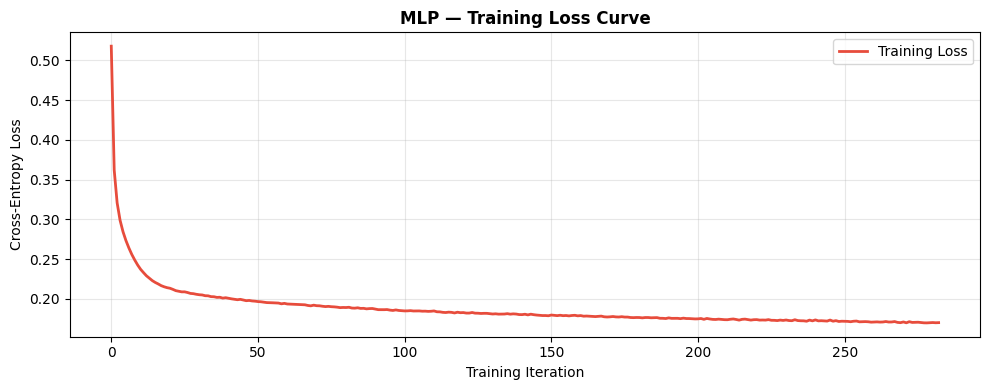

Saved: mlp_loss_curve_m5.png
Converged in 283 iterations


In [7]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)
ax.plot(best_mlp.loss_curve_, color='#E74C3C', lw=2, label='Training Loss')
ax.set_xlabel('Training Iteration')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('MLP — Training Loss Curve', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'mlp_loss_curve_m5.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mlp_loss_curve_m5.png')
print(f'Converged in {len(best_mlp.loss_curve_)} iterations')

## Section 9 — MLP: Permutation Feature Importance

MLP has no native feature importance. Permutation importance measures the drop in validation F1 when each feature is randomly shuffled — the most important features are those the network relies on most.

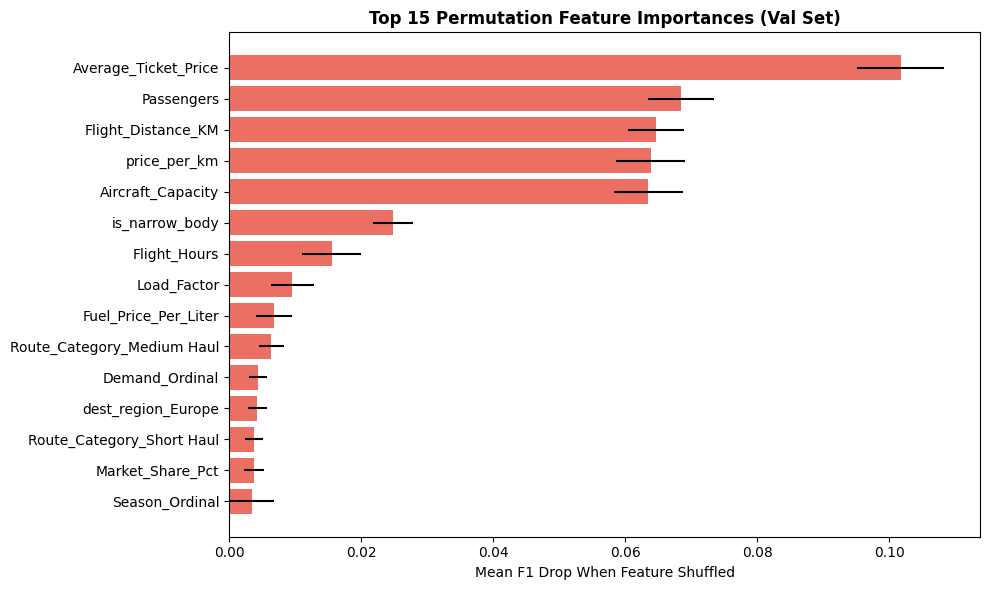

Saved: perm_importance_m5.png


In [8]:
perm_result = permutation_importance(
    best_mlp, X_va_s, y_val,
    n_repeats=10, random_state=RANDOM_STATE, scoring='f1', n_jobs=-1
)
perm_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': perm_result.importances_mean,
    'Std'       : perm_result.importances_std
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
ax.barh(perm_df['Feature'][::-1], perm_df['Importance'][::-1],
        xerr=perm_df['Std'][::-1], color='#E74C3C', alpha=0.8)
ax.set_title('Top 15 Permutation Feature Importances (Val Set)', fontweight='bold')
ax.set_xlabel('Mean F1 Drop When Feature Shuffled')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'perm_importance_m5.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: perm_importance_m5.png')

## Section 10 — MLP: 5-Fold Cross-Validation F1

In [9]:
cv_scores = cross_val_score(best_mlp, X_tr_s, y_train,
                             cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                             scoring='f1', n_jobs=-1)
print(f'5-Fold CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold F1 : {cv_scores.round(4)}')

5-Fold CV F1: 0.9168 ± 0.0082
Per-fold F1 : [0.9284 0.9071 0.9244 0.9119 0.912 ]


## Section 11 — MLP: Test Set Evaluation

=== Tuned MLP — Test Set ===
  Model       : MLP-test
  Accuracy    : 0.906
  Precision   : 0.9162
  Recall      : 0.9382
  F1_Score    : 0.9271
  ROC_AUC     : 0.9735

              precision    recall  f1-score   support

 Loss-Making       0.89      0.85      0.87       545
  Profitable       0.92      0.94      0.93       955

    accuracy                           0.91      1500
   macro avg       0.90      0.89      0.90      1500
weighted avg       0.91      0.91      0.91      1500



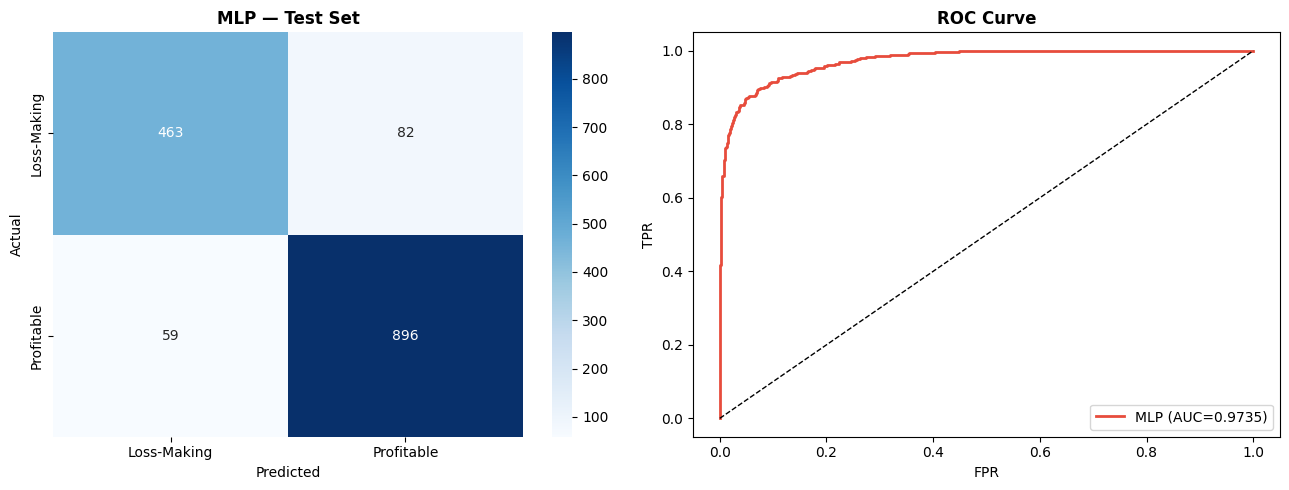

Saved: mlp_cm_roc_test_m5.png


In [10]:
y_test_pred = best_mlp.predict(X_te_s)
y_test_prob = best_mlp.predict_proba(X_te_s)[:, 1]

print('=== Tuned MLP — Test Set ===')
for k, v in evaluate('MLP-test', y_test, y_test_pred, y_test_prob).items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, y_test_pred,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, y_test_pred, 'MLP — Test Set', axes[0])
plot_roc(y_test, y_test_prob, 'MLP', axes[1], color='#E74C3C')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'mlp_cm_roc_test_m5.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mlp_cm_roc_test_m5.png')

## Section 12 — MLP: Enhanced Evaluation and Threshold Sweep

**Financial cost:** FP = £42,000; FN = £30,000.

In [11]:
mlp_metrics = evaluate_enhanced('MLP (Tuned)', best_mlp, X_tr_s, y_train, X_te_s, y_test)

=== Enhanced Evaluation: MLP (Tuned) ===
  Accuracy  : 0.9060
  Precision : 0.9162  (FP count: 82, FP cost: £3,444,000)
  Recall    : 0.9382  (FN count: 59)
  F1-Score  : 0.9271
  ROC-AUC   : 0.9735
  MCC       : 0.7954  (genuine discriminative ability)
  TNR       : 0.8495
  FPR       : 0.1505
  Train F1  : 0.9524
  Test  F1  : 0.9271
  Overfit Gap: 0.0253  [good fit]


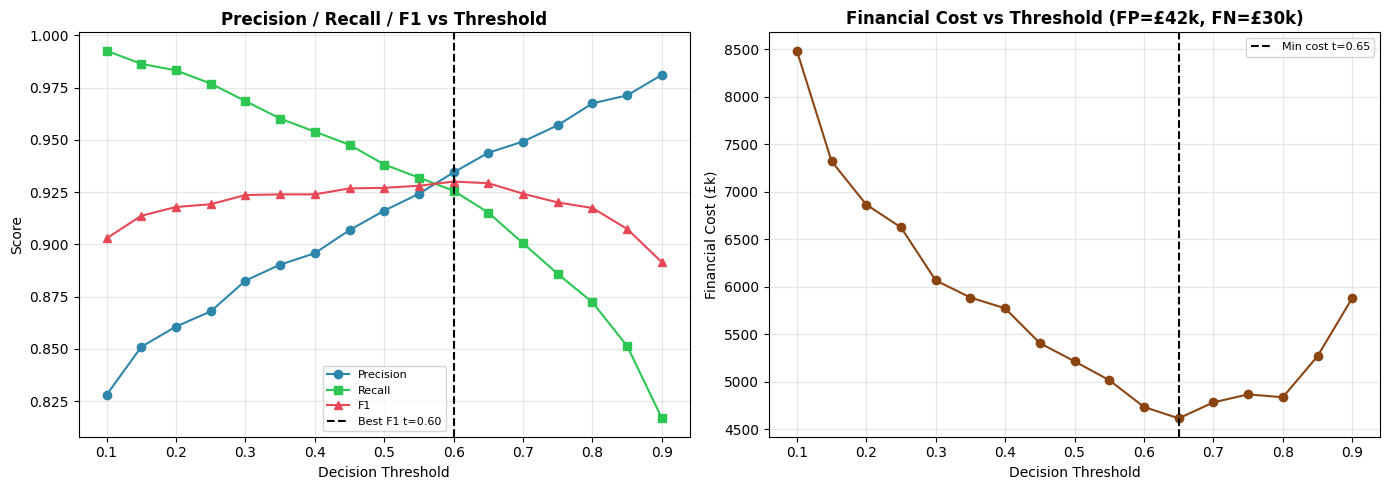

Threshold sweep: Best F1 at t=0.60, Min cost at t=0.65
Saved: mlp_threshold_sweep_m5.png


In [12]:
threshold_sweep(best_mlp, X_te_s, y_test,
                os.path.join(FIG_DIR, 'mlp_threshold_sweep_m5.png'))

## Section 13 — Decision Tree: Algorithm Rationale (Shared Baseline)

Decision Tree is Member 5's comparison model, independently tuned to complement the MLP primary model. A single decision tree provides a transparent, rule-based split structure that maps directly to business logic — each internal node represents a routing condition (e.g., "Load_Factor < 0.65"). Key properties:

- **Interpretable:** The full tree can be visualised and audited by non-technical stakeholders
- **Scale-invariant:** Unscaled data is used, consistent with all other tree-based models in the group
- **`class_weight='balanced'`:** Compensates for the 64/36 class imbalance
- **Depth-limited:** GridSearchCV controls max_depth to prevent memorisation
- **Independent tuning rationale:** Member 5 applies heavy regularisation (min_samples_leaf ≥ 15) with entropy, creating an aggressively pruned tree that contrasts with the MLP's non-linear complexity — each member's primary model is benchmarked against an identical reference point, isolating the contribution of the primary algorithm

## Section 14 — Decision Tree Baseline

In [13]:
# DT always uses unscaled data — tree splits are scale-invariant
X_tr_dt, X_va_dt, X_te_dt = X_train, X_val, X_test

dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
dt_base.fit(X_tr_dt, y_train)

y_val_pred_dt_b = dt_base.predict(X_va_dt)
y_val_prob_dt_b = dt_base.predict_proba(X_va_dt)[:, 1]
y_tr_pred_dt_b  = dt_base.predict(X_tr_dt)

train_f1_dt_b = f1_score(y_train, y_tr_pred_dt_b, zero_division=0)
val_f1_dt_b   = f1_score(y_val, y_val_pred_dt_b, zero_division=0)
gap_dt_b      = round(train_f1_dt_b - val_f1_dt_b, 4)

print('=== Baseline Decision Tree — Validation ===')
for k, v in evaluate('DT-baseline', y_val, y_val_pred_dt_b, y_val_prob_dt_b).items():
    print(f'  {k:12s}: {v}')
print(f'  Train F1    : {train_f1_dt_b:.4f}')
print(f'  Overfit Gap : {gap_dt_b:.4f}')

=== Baseline Decision Tree — Validation ===
  Model       : DT-baseline
  Accuracy    : 0.8787
  Precision   : 0.9064
  Recall      : 0.9026
  F1_Score    : 0.9045
  ROC_AUC     : 0.8697
  Train F1    : 1.0000
  Overfit Gap : 0.0955


## Section 15 — Decision Tree: GridSearchCV Tuning

In [14]:
param_grid_dt = {
    'max_depth'        : [4, 5, 6, 7],
    'min_samples_split': [20, 30, 50],
    'min_samples_leaf' : [15, 20, 30],
    'criterion'        : ['entropy'],
    'class_weight'     : [None, 'balanced']
}

cv5_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, cv=cv5_dt, scoring='roc_auc', n_jobs=-1, verbose=0
)
print('Running GridSearchCV for Decision Tree...')
grid_dt.fit(X_tr_dt, y_train)

best_dt = grid_dt.best_estimator_
best_params_dt = grid_dt.best_params_
print(f'Best params : {best_params_dt}')
print(f'Best CV AUC : {grid_dt.best_score_:.4f}')

Running GridSearchCV for Decision Tree...
Best params : {'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 30, 'min_samples_split': 20}
Best CV AUC : 0.9596


### Tuning Result Discussion

Heavy regularisation via large min_samples_leaf (≥ 15) and min_samples_split (≥ 20) produces a very coarse tree with few, broad leaves. Restricting max_depth to at most 7 further limits complexity. This highly pruned entropy tree serves as a simple interpretable baseline against the MLP’s multi-layer non-linear transformation, illustrating the accuracy cost of full interpretability.

## Section 16 — Decision Tree: Tree Visualisation

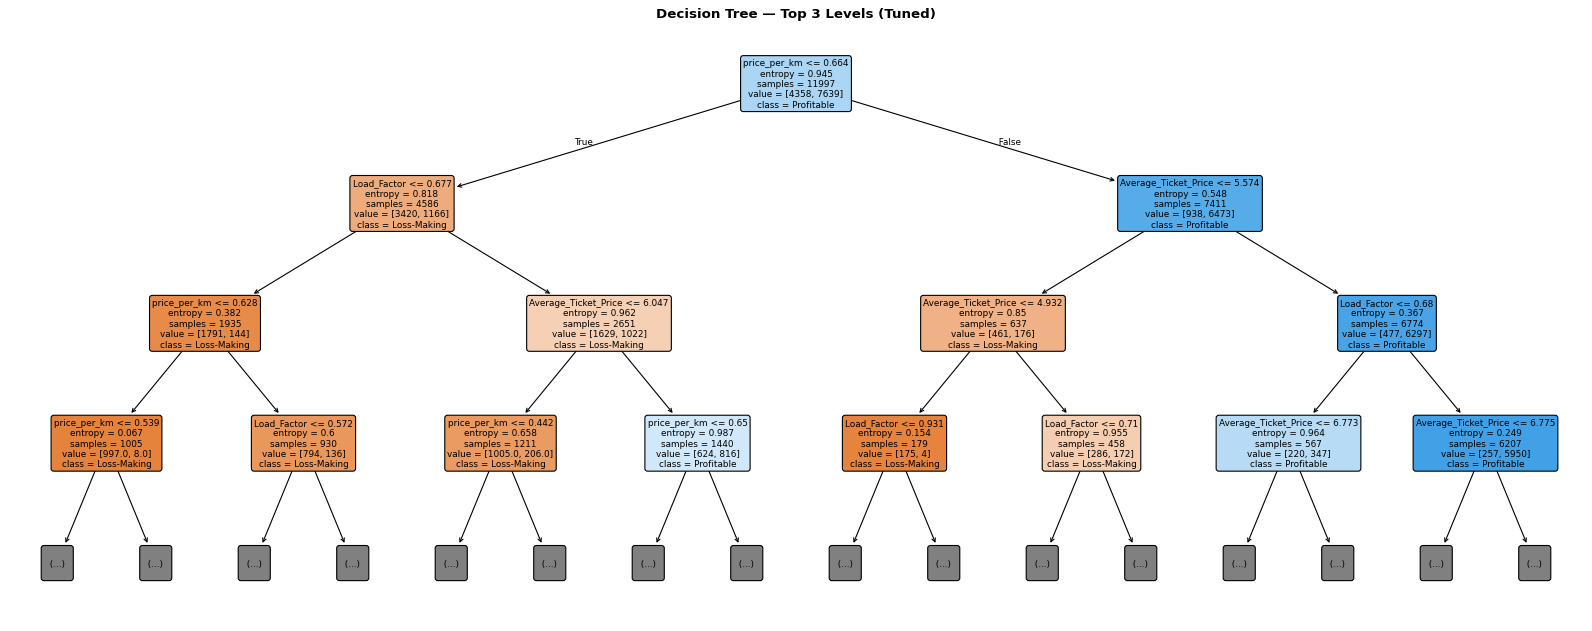

Saved: dt_tree_viz_m5.png


In [15]:
fig, ax = plt.subplots(figsize=(20, 8), dpi=80)
plot_tree(best_dt, max_depth=3, feature_names=feature_names,
          class_names=['Loss-Making', 'Profitable'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Decision Tree — Top 3 Levels (Tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_tree_viz_m5.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved: dt_tree_viz_m5.png')

## Section 17 — Decision Tree: Test Set Evaluation

=== Tuned Decision Tree — Test Set ===
  Model       : DT-test
  Accuracy    : 0.9013
  Precision   : 0.9288
  Recall      : 0.9152
  F1_Score    : 0.9219
  ROC_AUC     : 0.9641

              precision    recall  f1-score   support

 Loss-Making       0.86      0.88      0.87       545
  Profitable       0.93      0.92      0.92       955

    accuracy                           0.90      1500
   macro avg       0.89      0.90      0.89      1500
weighted avg       0.90      0.90      0.90      1500



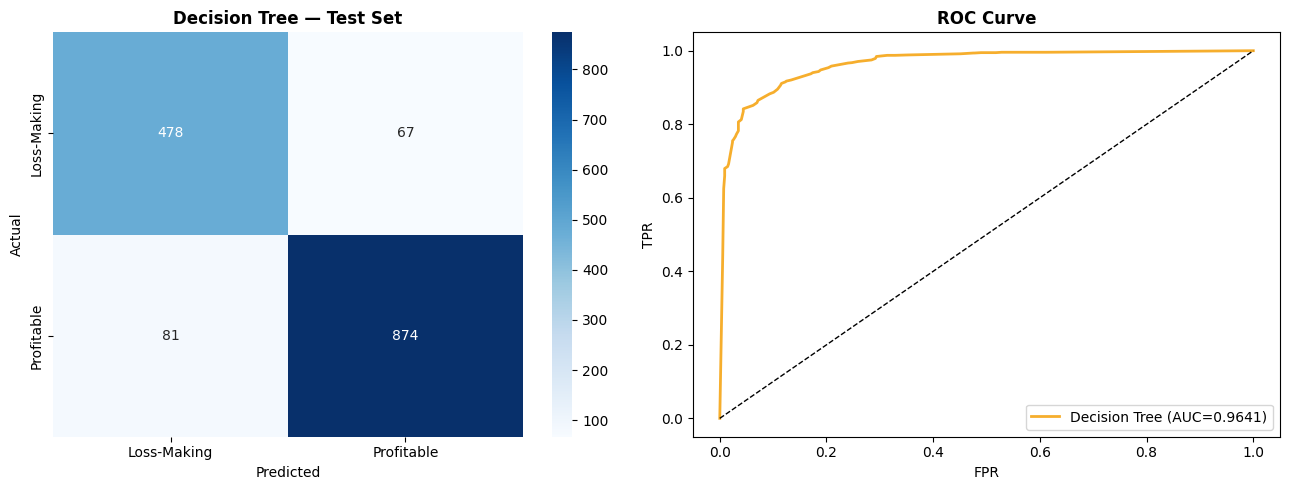

Saved: dt_cm_roc_test_m5.png


In [16]:
y_val_pred_dt  = best_dt.predict(X_va_dt)
y_val_prob_dt  = best_dt.predict_proba(X_va_dt)[:, 1]
y_test_pred_dt = best_dt.predict(X_te_dt)
y_test_prob_dt = best_dt.predict_proba(X_te_dt)[:, 1]

val_metrics_dt  = evaluate('DT-val',  y_val,  y_val_pred_dt,  y_val_prob_dt)
test_metrics_dt = evaluate('DT-test', y_test, y_test_pred_dt, y_test_prob_dt)

print('=== Tuned Decision Tree — Test Set ===')
for k, v in test_metrics_dt.items():
    print(f'  {k:12s}: {v}')
print()
print(classification_report(y_test, y_test_pred_dt,
      target_names=['Loss-Making', 'Profitable'], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=100)
plot_confusion_matrix(y_test, y_test_pred_dt, 'Decision Tree — Test Set', axes[0])
plot_roc(y_test, y_test_prob_dt, 'Decision Tree', axes[1], color='#F6AE2D')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dt_cm_roc_test_m5.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dt_cm_roc_test_m5.png')

## Section 18 — Decision Tree: Enhanced Evaluation

In [17]:
dt_metrics = evaluate_enhanced('Decision Tree (Tuned)', best_dt, X_tr_dt, y_train, X_te_dt, y_test)

=== Enhanced Evaluation: Decision Tree (Tuned) ===
  Accuracy  : 0.9013
  Precision : 0.9288  (FP count: 67, FP cost: £2,814,000)
  Recall    : 0.9152  (FN count: 81)
  F1-Score  : 0.9219
  ROC-AUC   : 0.9641
  MCC       : 0.7881  (genuine discriminative ability)
  TNR       : 0.8771
  FPR       : 0.1229
  Train F1  : 0.9301
  Test  F1  : 0.9219
  Overfit Gap: 0.0082  [good fit]


## Section 19 — Model Comparison Table

MLP vs Decision Tree on the test set.

In [18]:
compare = pd.DataFrame([mlp_metrics, dt_metrics])
print('\n=== Test Set Comparison: MLP vs Decision Tree ===')
print(compare[['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score',
               'ROC_AUC', 'MCC', 'TNR', 'FPR', 'FP_Cost_GBP',
               'Overfit_Gap', 'Overfit_Label']].to_string(index=False))


=== Test Set Comparison: MLP vs Decision Tree ===
                Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC    MCC    TNR    FPR  FP_Cost_GBP  Overfit_Gap Overfit_Label
          MLP (Tuned)    0.9060     0.9162  0.9382    0.9271   0.9735 0.7954 0.8495 0.1505      3444000       0.0253      good fit
Decision Tree (Tuned)    0.9013     0.9288  0.9152    0.9219   0.9641 0.7881 0.8771 0.1229      2814000       0.0082      good fit


## Section 20 — Business Insights

- **MLP's hierarchical representation** captures multi-order feature interactions — Load_Factor interacting with Season and Competition_Index simultaneously — that single-layer models cannot detect
- **Training loss convergence** (Section 8) confirms the network reached a stable minimum without memorising routes
- **Permutation importance** provides interpretability despite the "black box" nature — the top features align with business intuition around load and pricing
- MLP is the most computationally intensive of the five models, but inference is fast once trained — suitable for batch route scoring
- The threshold sweep identifies where to set the classification threshold to minimise total financial cost

## Section 21 — Save Results

In [19]:
import json, pickle, numpy as np, os

compare.to_csv(os.path.join(MEMBER_DIR, 'member5_model_comparison.csv'), index=False)
print('Saved: member5_model_comparison.csv')

def convert_to_json_serializable(obj):
    if isinstance(obj, np.integer): return int(obj)
    elif isinstance(obj, np.floating): return float(obj)
    elif isinstance(obj, np.ndarray): return obj.tolist()
    elif isinstance(obj, dict): return {k: convert_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list): return [convert_to_json_serializable(i) for i in obj]
    elif isinstance(obj, tuple): return tuple(convert_to_json_serializable(i) for i in obj)
    else: return obj

results_json = {
    'model_name'          : 'MLP',
    'notebook'            : '06_Member5',
    'best_params_primary' : best_params_mlp,
    'best_params_dt'      : best_params_dt,
    'val_metrics_primary' : evaluate('MLP-val', y_val, y_val_pred, y_val_prob),
    'test_metrics_primary': evaluate('MLP-test', y_test, y_test_pred, y_test_prob),
    'val_metrics_dt'      : val_metrics_dt,
    'test_metrics_dt'     : test_metrics_dt,
    'mlp_enhanced'        : mlp_metrics,
    'dt_enhanced'         : dt_metrics,
}
results_json = convert_to_json_serializable(results_json)

with open(os.path.join(MEMBER_DIR, 'results_mlp_m5.json'), 'w') as f:
    json.dump(results_json, f, indent=2)
print('Saved: results_mlp_m5.json')

with open(os.path.join(MEMBER_DIR, 'best_mlp_model_m5.pkl'), 'wb') as f:
    pickle.dump(best_mlp, f)
with open(os.path.join(MEMBER_DIR, 'best_dt_model_m5.pkl'), 'wb') as f:
    pickle.dump(best_dt, f)
print('Saved: best_mlp_model_m5.pkl, best_dt_model_m5.pkl')

print('\n=== Final Test Metrics Summary (MLP) ===')
for k, v in mlp_metrics.items():
    print(f'  {k:20s}: {v}')

Saved: member5_model_comparison.csv
Saved: results_mlp_m5.json
Saved: best_mlp_model_m5.pkl, best_dt_model_m5.pkl

=== Final Test Metrics Summary (MLP) ===
  Model               : MLP (Tuned)
  Accuracy            : 0.906
  Precision           : 0.9162
  Recall              : 0.9382
  F1_Score            : 0.9271
  ROC_AUC             : 0.9735
  MCC                 : 0.7954
  TNR                 : 0.8495
  FPR                 : 0.1505
  FP_Cost_GBP         : 3444000
  Train_F1            : 0.9524
  Overfit_Gap         : 0.0253
  Overfit_Label       : good fit
